# 任务3_2_1 DIFFUSION模型(扩散模型)
本次任务的目标是实现一个简单的扩散模型，并使用它来生成图像。扩散模型是一种基于概率的生成模型，通过逐步添加噪声来生成数据。

## 1.环境设置与超参数
这里我们依然使用MNIST数据集。并将t设置为100步

In [31]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # 预防绘图崩溃

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 课件 P43 超参数设置
timesteps = 100
epochs = 100
batch_size = 128
learning_rate = 2e-4

## 2. 加载 MNIST 数据集
与 3_1_1 类似，使用 `torchvision.datasets.MNIST` 加载数据。

In [32]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 将像素归一化到 [-1, 1]
])

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print(f"训练集样本数: {len(train_dataset)}")

训练集样本数: 60000


## 3. 前向扩散过程（q）
按课件设置线性噪声调度，定义 $q(x_t|x_0)$。

In [33]:
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, device=device)
    alphas_bar = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi / 2) ** 2
    alphas_bar = alphas_bar / alphas_bar[0]
    betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])
    return torch.clamp(betas, 1e-4, 0.999)


betas = cosine_beta_schedule(timesteps)
alphas = 1.0 - betas
alphas_bar = torch.cumprod(alphas, dim=0)


def extract(a, t, x_shape):
    batch_size = t.size(0)
    out = a.gather(0, t).float()
    return out.view(batch_size, *((1,) * (len(x_shape) - 1)))


def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab = torch.sqrt(extract(alphas_bar, t, x0.shape))
    sqrt_one_minus_ab = torch.sqrt(1.0 - extract(alphas_bar, t, x0.shape))
    return sqrt_ab * x0 + sqrt_one_minus_ab * noise

## 4. 构建去噪模型
输入 $x_t$ 和时间步 $t$，预测噪声 $\epsilon_\theta(x_t,t)$。

In [34]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_channels)

    def forward(self, x, t_emb):
        h = F.relu(self.conv1(x))
        h = h + self.time_proj(t_emb).view(t_emb.size(0), -1, 1, 1)
        h = F.relu(self.conv2(h))
        return h


class UNetSmall(nn.Module):
    def __init__(self, time_dim=128):
        super().__init__()
        self.time_emb = nn.Sequential(
            nn.Embedding(timesteps, time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU(inplace=True),
            nn.Linear(time_dim, time_dim),
        )
        self.down1 = ConvBlock(1, 64, time_dim)
        self.down2 = ConvBlock(64, 128, time_dim)
        self.down3 = ConvBlock(128, 256, time_dim)
        self.pool = nn.MaxPool2d(2)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up2 = ConvBlock(256, 128, time_dim)
        self.conv_up1 = ConvBlock(128, 64, time_dim)
        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_emb(t)
        x1 = self.down1(x, t_emb)
        x2 = self.down2(self.pool(x1), t_emb)
        x3 = self.down3(self.pool(x2), t_emb)
        x = self.up2(x3)
        x = torch.cat([x2, x], dim=1)
        x = self.conv_up2(x, t_emb)
        x = self.up1(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv_up1(x, t_emb)
        return self.out(x)


model = UNetSmall().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

## 5. 训练模型
目标是让模型预测前向扩散中加入的噪声。

In [35]:
loss_history = []
print("开始训练扩散模型...")
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    for x0, _ in train_loader:
        x0 = x0.to(device)
        t = torch.randint(0, timesteps, (x0.size(0),), device=device).long()
        noise = torch.randn_like(x0)
        x_t = q_sample(x0, t, noise)
        pred_noise = model(x_t, t)
        loss = F.mse_loss(pred_noise, noise)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * x0.size(0)
    avg_loss = total_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.6f}")

开始训练扩散模型...
Epoch 01 | Loss: 0.181546
Epoch 02 | Loss: 0.073727
Epoch 03 | Loss: 0.063555
Epoch 04 | Loss: 0.057625
Epoch 05 | Loss: 0.054449
Epoch 06 | Loss: 0.052006
Epoch 07 | Loss: 0.049755
Epoch 08 | Loss: 0.048639
Epoch 09 | Loss: 0.047147
Epoch 10 | Loss: 0.046809
Epoch 11 | Loss: 0.045160
Epoch 12 | Loss: 0.044750
Epoch 13 | Loss: 0.044311
Epoch 14 | Loss: 0.043649
Epoch 15 | Loss: 0.043534
Epoch 16 | Loss: 0.043200
Epoch 17 | Loss: 0.042538
Epoch 18 | Loss: 0.041879
Epoch 19 | Loss: 0.041968
Epoch 20 | Loss: 0.041775
Epoch 21 | Loss: 0.041403
Epoch 22 | Loss: 0.041737
Epoch 23 | Loss: 0.040815
Epoch 24 | Loss: 0.040781
Epoch 25 | Loss: 0.040863
Epoch 26 | Loss: 0.040467
Epoch 27 | Loss: 0.040359
Epoch 28 | Loss: 0.040250
Epoch 29 | Loss: 0.040123
Epoch 30 | Loss: 0.039966
Epoch 31 | Loss: 0.039748
Epoch 32 | Loss: 0.039550
Epoch 33 | Loss: 0.039564
Epoch 34 | Loss: 0.039524
Epoch 35 | Loss: 0.039018
Epoch 36 | Loss: 0.039163
Epoch 37 | Loss: 0.039334
Epoch 38 | Loss: 0.039002


KeyboardInterrupt: 

## 6. 训练过程可视化

ValueError: x and y must have same first dimension, but have shapes (100,) and (59,)

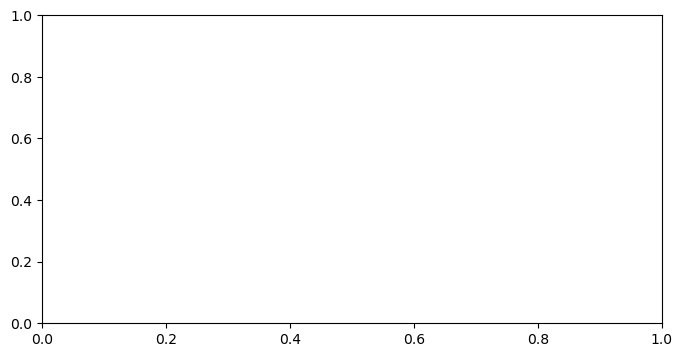

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), loss_history, marker="o")
plt.title("Diffusion Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.show()

## 7. 反向采样与生成可视化

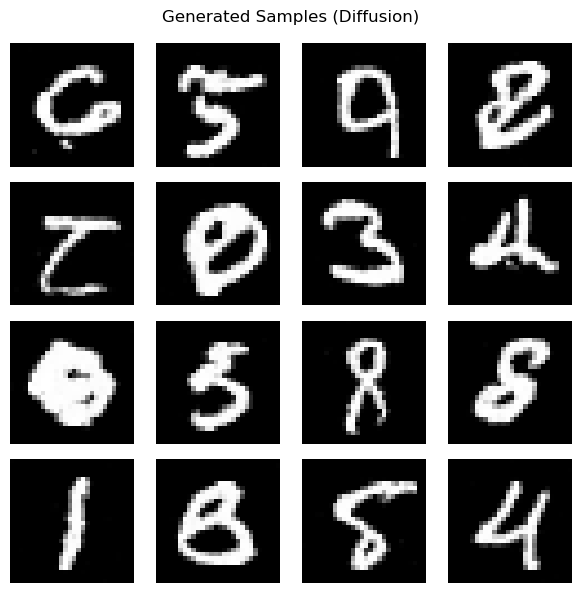

In [37]:
@torch.no_grad()
def p_sample(model, x, t):
    betas_t = extract(betas, t, x.shape)
    alphas_t = extract(alphas, t, x.shape)
    alphas_bar_t = extract(alphas_bar, t, x.shape)
    eps_theta = model(x, t)
    mean = (1.0 / torch.sqrt(alphas_t)) * (x - (betas_t / torch.sqrt(1.0 - alphas_bar_t)) * eps_theta)
    noise = torch.randn_like(x)
    mask = (t > 0).float().view(x.size(0), 1, 1, 1)
    return mean + torch.sqrt(betas_t) * noise * mask


@torch.no_grad()
def sample(model, n=16):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)
    for i in reversed(range(timesteps)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t)
    x = x.clamp(-1, 1)
    x = (x + 1) / 2
    return x.cpu()


samples = sample(model, n=16)
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i].squeeze(0), cmap="gray")
    ax.axis("off")
plt.suptitle("Generated Samples (Diffusion)")
plt.tight_layout()
plt.show()